<a href="https://colab.research.google.com/github/chamarairesh1982/LearnPython/blob/main/Week3_Feature_Engineering_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering


This notebook is a hands-on companion to **Lecture 3, Slides 8–35 (Feature Engineering)**.

Last week you practiced **Data Preprocessing** (handling missing values, duplicates, and inconsistencies). This week's dataset is **already cleaned**, so we can focus entirely on **Feature Engineering**:


In [1]:
# Import the libraries we'll need throughout the notebook
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
)
from sklearn.feature_selection import (
    SelectKBest, chi2, f_classif, VarianceThreshold, RFE
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
np.random.seed(42)

print("Libraries loaded ✅")

Libraries loaded ✅


## Create the Practice Dataset

Consider the **Student Exam Performance** dataset, the same scenario used in the lecture examples (Study Hours, Attendance, Assignment Marks → Predicting Pass/Fail).

The dataset below is generated directly from a DataFrame (`pd.DataFrame`) and is **already handled for missing values and duplicates**.

In [3]:
n = 300  # number of students

# --- Raw / original features (Slide 13: "Raw Features") ---
student_id = [f"S{1000+i}" for i in range(n)]
hours_studied = np.round(np.random.normal(15, 5, n).clip(1, 40), 1)
days_studied = np.random.randint(1, 10, n)
attendance_pct = np.round(np.random.normal(75, 15, n).clip(30, 100), 1)

# Three separate test scores (raw) - we'll aggregate these later
test_1 = np.round(np.random.normal(60, 12, n).clip(0, 100), 1)
test_2 = np.round(np.random.normal(65, 12, n).clip(0, 100), 1)
test_3 = np.round(np.random.normal(68, 12, n).clip(0, 100), 1)

age = np.random.randint(18, 30, n)
height_cm = np.round(np.random.normal(165, 9, n), 1)
weight_kg = np.round(np.random.normal(62, 11, n), 1)

# Deliberately skewed income (great for demonstrating log transformation)
annual_income = np.round(np.random.lognormal(mean=10.4, sigma=0.6, size=n), 2)

education_level = np.random.choice(
    ["High School", "Bachelor's", "Master's"], size=n, p=[0.30, 0.50, 0.20]
)
learning_mode = np.random.choice(
    ["Online", "Offline", "Hybrid"], size=n, p=[0.40, 0.35, 0.25]
)
enrollment_date = pd.to_datetime(
    np.random.choice(pd.date_range("2023-01-01", "2024-12-31"), size=n)
)

df = pd.DataFrame({
    "Student_ID": student_id,
    "Hours_Studied": hours_studied,
    "Days_Studied": days_studied,
    "Attendance_Percentage": attendance_pct,
    "Test_1": test_1,
    "Test_2": test_2,
    "Test_3": test_3,
    "Age": age,
    "Height_cm": height_cm,
    "Weight_kg": weight_kg,
    "Annual_Income": annual_income,
    "Education_Level": education_level,
    "Preferred_Learning_Mode": learning_mode,
    "Enrollment_Date": enrollment_date,
})

# --- Create a realistic target variable: Pass (Yes/No) ---
avg_test = df[["Test_1", "Test_2", "Test_3"]].mean(axis=1)
score = (
    0.05 * df["Hours_Studied"]
    + 0.03 * df["Attendance_Percentage"]
    + 0.06 * avg_test
    + np.random.normal(0, 3, n)
)
threshold = np.percentile(score, 40)
df["Pass"] = np.where(score >= threshold, "Yes", "No")

print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum(), "(already handled ✅)")
print("Duplicate rows:", df.duplicated().sum(), "(already handled ✅)")
df.head()

Dataset shape: (300, 15)

Missing values:
 0 (already handled ✅)
Duplicate rows: 0 (already handled ✅)


,Student_ID,Hours_Studied,Days_Studied,Attendance_Percentage,Test_1,Test_2,Test_3,Age,Height_cm,Weight_kg,Annual_Income,Education_Level,Preferred_Learning_Mode,Enrollment_Date,Pass
0,S1000,20.4,6,64.9,63.8,56.0,47.2,22,174.3,80.9,24647.44,High School,Online,2023-07-05,Yes
1,S1001,14.3,2,51.4,57.8,40.5,70.7,25,171.1,64.2,13568.65,High School,Hybrid,2023-09-18,No
2,S1002,3.6,5,63.1,66.0,63.8,69.0,19,161.5,51.3,26015.54,Bachelor's,Hybrid,2024-06-11,Yes
3,S1003,25.7,6,77.2,56.5,69.5,62.9,22,167.9,69.7,137155.04,High School,Hybrid,2023-09-30,Yes
4,S1004,21.2,5,71.9,63.5,54.7,73.9,29,176.3,58.9,9075.26,High School,Hybrid,2023-06-09,No


## 1. Feature Creation

Feature Creation builds new features from existing ones using math, domain knowledge, or summarization.

### 1.1 Mathematical Features
Example from the slides: `Average Study Hours per Day = Hours Studied ÷ Days Studied`.

In [4]:
df["Avg_Study_Hours_Per_Day"] = df["Hours_Studied"] / df["Days_Studied"]
df[["Hours_Studied", "Days_Studied", "Avg_Study_Hours_Per_Day"]].head()

,Hours_Studied,Days_Studied,Avg_Study_Hours_Per_Day
0,20.4,6,3.400000
1,14.3,2,7.150000
2,3.6,5,0.720000
3,25.7,6,4.283333
4,21.2,5,4.240000


### 1.2 Aggregation Features
We summarize the three separate test scores (`Test_1`, `Test_2`, `Test_3`) into a single `Average_Test_Score`

In [5]:
df["Average_Test_Score"] = df[["Test_1", "Test_2", "Test_3"]].mean(axis=1)
df[["Test_1", "Test_2", "Test_3", "Average_Test_Score"]].head()

,Test_1,Test_2,Test_3,Average_Test_Score
0,63.8,56.0,47.2,55.666667
1,57.8,40.5,70.7,56.333333
2,66.0,63.8,69.0,66.266667
3,56.5,69.5,62.9,62.966667
4,63.5,54.7,73.9,64.033333


### 1.3 Interaction Features
Interaction features combine two or more existing features. Here we combine study effort and attendance.

In [6]:
df["Study_Attendance_Interaction"] = df["Hours_Studied"] * df["Attendance_Percentage"]
df[["Hours_Studied", "Attendance_Percentage", "Study_Attendance_Interaction"]].head()

,Hours_Studied,Attendance_Percentage,Study_Attendance_Interaction
0,20.4,64.9,1323.96
1,14.3,51.4,735.02
2,3.6,63.1,227.16
3,25.7,77.2,1984.04
4,21.2,71.9,1524.28


### 1.4 Date/Time Features
We extract useful signals from `Enrollment_Date`: month, quarter, day of week, and whether enrollment happened on a weekend.

In [7]:
df["Enrollment_Month"] = df["Enrollment_Date"].dt.month
df["Enrollment_Quarter"] = df["Enrollment_Date"].dt.quarter
df["Enrollment_DayOfWeek"] = df["Enrollment_Date"].dt.day_name()
df["Enrollment_IsWeekend"] = df["Enrollment_Date"].dt.dayofweek.isin([5, 6])

df[["Enrollment_Date", "Enrollment_Month", "Enrollment_Quarter",
    "Enrollment_DayOfWeek", "Enrollment_IsWeekend"]].head()

,Enrollment_Date,Enrollment_Month,Enrollment_Quarter,Enrollment_DayOfWeek,Enrollment_IsWeekend
0,2023-07-05,7,3,Wednesday,False
1,2023-09-18,9,3,Monday,False
2,2024-06-11,6,2,Tuesday,False
3,2023-09-30,9,3,Saturday,True
4,2023-06-09,6,2,Friday,False


### 1.5 Domain-Specific Features
  Compute **BMI** (`Weight / Height²`) and
  **Study Efficiency** (score earned per hour studied).

In [8]:
df["BMI"] = df["Weight_kg"] / (df["Height_cm"] / 100) ** 2
df["Study_Efficiency"] = df["Average_Test_Score"] / df["Hours_Studied"]

df[["Weight_kg", "Height_cm", "BMI", "Average_Test_Score", "Hours_Studied", "Study_Efficiency"]].head()

,Weight_kg,Height_cm,BMI,Average_Test_Score,Hours_Studied,Study_Efficiency
0,80.9,174.3,26.628932,55.666667,20.4,2.728758
1,64.2,171.1,21.929817,56.333333,14.3,3.939394
2,51.3,161.5,19.668549,66.266667,3.6,18.407407
3,69.7,167.9,24.724720,62.966667,25.7,2.450065
4,58.9,176.3,18.950064,64.033333,21.2,3.020440


## 2. Feature Transformation

**Feature Scaling** rescales numeric features into a specific range.

### 2.1 Min-Max Scaling (Normalization)
Transforms values into a fixed range, usually **[0, 1]**. It preserves the shape of the original distribution but is **sensitive to outliers**.

$$ x' = \frac{x - x_{min}}{x_{max} - x_{min}} $$

In [9]:
minmax_scaler = MinMaxScaler()
df["Hours_Studied_MinMax"] = minmax_scaler.fit_transform(df[["Hours_Studied"]])
df[["Hours_Studied", "Hours_Studied_MinMax"]].describe()

,Hours_Studied,Hours_Studied_MinMax
count,300.000000,300.000000
mean,15.482000,0.413882
std,5.141959,0.169143
min,2.900000,0.000000
25%,11.900000,0.296053
50%,15.550000,0.416118
75%,18.625000,0.517270
max,33.300000,1.000000


# 2.2 Standardization (Z-score Normalization)
Transforms data to have **mean = 0** and **standard deviation = 1**. More robust when data is roughly Gaussian, and less (but not completely) sensitive to outliers.

$$ z = \frac{x - \mu}{\sigma} $$

In [10]:
std_scaler = StandardScaler()
df["Attendance_Standardized"] = std_scaler.fit_transform(df[["Attendance_Percentage"]])

#print("Mean:", df["Attendance_Standardized"].mean().round(4))
#print("Std :", df["Attendance_Standardized"].std().round(4))
print("Mean:", round(df["Attendance_Standardized"].mean(), 4))
print("Std :", round(df["Attendance_Standardized"].std(), 4))
df[["Attendance_Percentage", "Attendance_Standardized"]].head()

Mean: 0.0
Std : 1.0017


,Attendance_Percentage,Attendance_Standardized
0,64.9,-0.632882
1,51.4,-1.562646
2,63.1,-0.756851
3,77.2,0.214236
4,71.9,-0.150782


### 2.3 Log Transformation
Reduces **skewness** by compressing large values — great for right-skewed data like income. Let's visualize `Annual_Income` before and after.

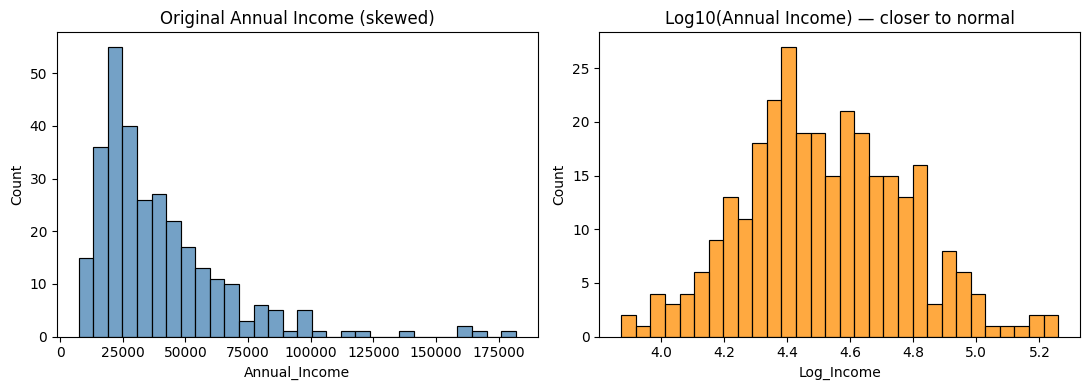

In [11]:
df["Log_Income"] = np.log10(df["Annual_Income"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Annual_Income"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Original Annual Income (skewed)")
sns.histplot(df["Log_Income"], bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Log10(Annual Income) — closer to normal")
plt.tight_layout()
plt.show()

### 2.4 Polynomial Features
Adds squared/cubic (higher-order) terms so a linear model can capture **curved (nonlinear)** relationships — e.g., exam marks that increase rapidly after a certain number of study hours.

In [ ]:
poly = PolynomialFeatures(degree=3, include_bias=False)
poly_features = poly.fit_transform(df[["Hours_Studied"]])

poly_df = pd.DataFrame(
    poly_features, columns=["Hours_Studied", "Hours_Studied^2", "Hours_Studied^3"]
)
poly_df.head()

## 3. Feature Encoding

ML models need **numeric** input, so categorical variables must be encoded.

- **Nominal variables** — no natural order (e.g., `Preferred_Learning_Mode`: Online/Offline/Hybrid) → **One-Hot Encoding**
- **Ordinal variables** — categories follow a ranking (e.g., `Education_Level`: High School < Bachelor's < Master's) → **Label Encoding**

### 3.1 Label Encoding (for Ordinal Variables)
Converts each category to a unique integer, respecting the natural order.

In [ ]:
education_order = {"High School": 0, "Bachelor's": 1, "Master's": 2}
df["Education_Level_Encoded"] = df["Education_Level"].map(education_order)

df[["Education_Level", "Education_Level_Encoded"]].drop_duplicates().sort_values("Education_Level_Encoded")

### 3.2 One-Hot Encoding (for Nominal Variables)
Creates one binary (0/1) column per category. There's no ranking implied between `Online`, `Offline`, and `Hybrid`, so one-hot encoding avoids introducing a false order.

In [ ]:
learning_mode_dummies = pd.get_dummies(df["Preferred_Learning_Mode"], prefix="Mode")
df = pd.concat([df, learning_mode_dummies], axis=1)

df[["Preferred_Learning_Mode"] + list(learning_mode_dummies.columns)].head()

## 4. Dimensionality Reduction

There are two families of techniques:
1. **Feature Selection** — pick a subset of existing features (Filter / Wrapper / Embedded methods)
2. **Feature Extraction** — transform features into a smaller set of new ones (e.g., PCA)

Let's build a clean numeric feature matrix first, then apply each method.

In [ ]:
# Encode the target for use in feature-selection models
df["Pass_Encoded"] = df["Pass"].map({"No": 0, "Yes": 1})

feature_cols = [
    "Hours_Studied", "Days_Studied", "Attendance_Percentage", "Average_Test_Score",
    "Age", "Height_cm", "Weight_kg", "Annual_Income", "BMI",
    "Study_Attendance_Interaction", "Education_Level_Encoded"
]

X = df[feature_cols].copy()
y = df["Pass_Encoded"].copy()
X.head()

### 4.1 Filter Methods
Filter methods score each feature using a **statistical test**, independent of any ML model. They're fast and model-agnostic but ignore feature interactions.


**a) Pearson Correlation** — measures the linear relationship between two numerical variables.

In [ ]:
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

**b) Chi-Square Test** — tests whether a categorical feature is associated with a categorical target. Test `Education_Level` vs. `Pass` (both categorical).

In [ ]:
contingency_table = pd.crosstab(df["Education_Level"], df["Pass"])
print("Contingency Table (Observed Frequencies):")
print(contingency_table)

from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.3f}")
if p_value < 0.05:
    print("Decision: p < 0.05 → Reject H0 → Education_Level and Pass are DEPENDENT (associated)")
else:
    print("Decision: p >= 0.05 → Fail to reject H0 → Education_Level and Pass are INDEPENDENT")

**c) ANOVA** — tests whether a numerical feature's mean differs significantly across categories of a categorical target. Test whether each feature differs meaningfully between `Pass = Yes` vs `Pass = No`.

In [ ]:
anova_scores, anova_pvalues = f_classif(X, y)

anova_results = pd.DataFrame({
    "Feature": feature_cols,
    "ANOVA_F_Score": anova_scores,
    "p_value": anova_pvalues
}).sort_values("ANOVA_F_Score", ascending=False)

anova_results

**d) Variance Threshold** — removes features with little to no variance (i.e., features that barely change and therefore carry little information).

In [ ]:
selector = VarianceThreshold(threshold=0.0)
selector.fit(X)

low_variance_report = pd.DataFrame({
    "Feature": feature_cols,
    "Variance": X.var().values,
    "Kept": selector.get_support()
})
low_variance_report

### 5.2 Wrapper Methods
Wrapper methods treat feature selection as a **search problem**: train a model on different feature subsets and keep the subset that performs best. More accurate than filter methods, but **computationally expensive**.

We'll use **Recursive Feature Elimination (RFE)** — it repeatedly builds a model, drops the weakest feature, and ranks all features by the order in which they were eliminated.

In [ ]:
# Scale features first so the underlying Logistic Regression converges reliably
X_scaled_for_models = StandardScaler().fit_transform(X)

log_reg = LogisticRegression(max_iter=2000)
rfe = RFE(estimator=log_reg, n_features_to_select=5)
rfe.fit(X_scaled_for_models, y)

rfe_results = pd.DataFrame({
    "Feature": feature_cols,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
}).sort_values("Rank")
rfe_results

# Feature Extraction — PCA

 **feature extraction** transforms the original features into a **smaller set of brand-new features**, automatically.

**Principal Component Analysis (PCA)** transforms correlated features into a smaller set of uncorrelated features called **Principal Components**, which capture as much of the original variance as possible.

> ⚠️ PCA is scale-sensitive — we must **standardize** the features first.

In [ ]:
pca_features = ["Height_cm", "Weight_kg", "Age", "Hours_Studied",
                 "Attendance_Percentage", "Average_Test_Score", "Annual_Income"]

X_pca_input = StandardScaler().fit_transform(df[pca_features])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_pca_input)

df["PC1"] = principal_components[:, 0]
df["PC2"] = principal_components[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total variance retained by PC1 + PC2:", pca.explained_variance_ratio_.sum().round(3))

df[["PC1", "PC2"]].head()

In [ ]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Pass", palette="Set1", alpha=0.7)
plt.title(f"7 original features compressed into 2 Principal Components\n"
          f"({pca.explained_variance_ratio_.sum()*100:.1f}% of variance retained)")
plt.tight_layout()
plt.show()

Instead of using all 7 original features (`Height_cm`, `Weight_kg`, `Age`, `Hours_Studied`, `Attendance_Percentage`, `Average_Test_Score`, `Annual_Income`), we can now use just **PC1** and **PC2** while retaining most of the underlying information.
